# A2: Foundation Foods EDA & Clustering

**Input:** foundation_analysis_ready.csv (output of A1)

**Output:** foundation_clustered.csv (with PCA1–PCA3 + Cluster labels)

**Purpose:** Exploratory analysis, 2D/3D PCA, K-Means + Hierarchical clustering
of 369 USDA Foundation Foods by nutrient density profile.


## Methodology

### Overview
This notebook performs unsupervised clustering of the 369 Foundation Foods using their nutrient density profiles (nutrients per 100 kcal). The goal is to discover natural groupings in nutritional space that go beyond simple food group labels — for example, separating high-fat plant foods (nuts, avocado) from lean meats even though both are protein sources.

### Feature Space
All clustering is performed on **nutrient density features** (columns ending in `_per_100kcal`). Using per-100-kcal normalization rather than per-100g ensures that foods are compared on an energy-equivalent basis — a tablespoon of olive oil and a chicken breast both provide energy, but their nutrient profiles per unit of energy are very different.

### Preprocessing
Features are standardized with `StandardScaler` (zero mean, unit variance) before PCA and clustering. This is essential: without scaling, high-magnitude nutrients (e.g., Sodium at hundreds of mg) would numerically dominate low-magnitude ones (e.g., Vitamin B12 at micrograms), and PCA would capture variance in measurement scale rather than actual nutritional structure.

### Dimensionality Reduction (PCA)
Principal Component Analysis is applied to the full nutrient density matrix. PC1 broadly captures the protein–fat axis (high protein pushes negative PC1, high fat pushes positive). PC2 captures micronutrient richness vs. empty calories. PC3 separates plant (fiber/potassium) from animal (cholesterol/B12) profiles. The first 3 PCs explain ~50–60% of total variance — sufficient for visualization but not for clustering, where the full feature space is retained.

### Clustering
Two algorithms are run in parallel on the full standardized feature space (not PCA-reduced):
- **K-Means** (K=7, chosen by elbow method): minimizes within-cluster variance, tends to produce spherical clusters of similar size.
- **Agglomerative Hierarchical** (Ward linkage, K=7): minimizes within-cluster variance at each merge step, handles non-spherical clusters better. This is the primary clustering used downstream.

A consensus heatmap (K-Means vs. Hierarchical) shows that the two algorithms broadly agree, lending confidence to the K=7 choice. A dendrogram on a 50-food random sample visualizes the merge hierarchy.

In [20]:
# ── Copied from A1 with attribution ──────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib.colors import SymLogNorm


In [21]:
PALETTE = {
    "meat_fish_eggs":     "#e74c3c",
    "fruits_veg_legumes": "#2ecc71",
    "cereals":            "#f39c12",
    "dairy":              "#3498db",
    "fats":               "#9b59b6",
    "condiments":         "#1abc9c",
    "beverages":          "#34495e",
    "sweets":             "#e91e63",
    "default":            "#95a5a6",
}

AGRIBALYSE_GROUP_LABELS = {
    "viandes, \u0153ufs, poissons":                     "meat_fish_eggs",
    "fruits, l\u00e9gumes, l\u00e9gumineuses et ol\u00e9agineux": "fruits_veg_legumes",
    "produits c\u00e9r\u00e9aliers":                          "cereals",
    "entr\u00e9es et plats compos\u00e9s":                    "prepared_meals",
    "lait et produits laitiers":                    "dairy",
    "aides culinaires et ingr\u00e9dients divers":       "condiments",
    "boissons":                                     "beverages",
    "mati\u00e8res grasses":                             "fats",
    "produits sucr\u00e9s":                              "sweets",
    "aliments infantiles":                          "infant",
    "glaces et sorbets":                            "ice_cream",
}


## 1. Load Data

In [22]:
df = pd.read_csv("foundation_analysis_ready.csv")

# NOWE: Usunięcie z grupowania produktów skrajnie niskokalorycznych
# (Zapobiega sztucznemu pompowaniu wartości "per_100kcal")

'''#optionally filter out low kcal products, as they are not relevant for diet optimization and can distort clustering
MIN_KCAL_FOR_CLUSTERING = 20.0

print(f"Liczba produktów przed filtrowaniem: {len(df)}")
df = df[df["Energy [kcal]"] >= MIN_KCAL_FOR_CLUSTERING].copy()
print(f"Liczba produktów po usunięciu niskokalorycznych: {len(df)}")
'''

df["group_en"] = df["co2_group"].map(AGRIBALYSE_GROUP_LABELS).fillna("other")
density_cols = [c for c in df.columns if c.endswith("_per_100kcal")]

print("Shape:", df.shape)
print("Density features:", len(density_cols))
df.head(3)


Shape: (357, 33)
Density features: 20


,description,Energy [kcal],Calcium_Ca_per_100kcal,Carbohydrate_by_difference_per_100kcal,Cholesterol_per_100kcal,Fatty_acids_total_monounsaturated_per_100kcal,Fatty_acids_total_polyunsaturated_per_100kcal,Fatty_acids_total_saturated_per_100kcal,Fatty_acids_total_trans_per_100kcal,Fiber_total_dietary_per_100kcal,...,co2_match,co2_group,co2_kg,co2_kg_final,correction_layer,bi_encoder_conf,cross_encoder_score,price_match,price_per_kg,group_en
0,"Almond butter, creamy",645.4560,40.870330,3.290179,0.0,5.374495,1.953658,0.658914,0.0,1.505602,...,Sugar-coated almond,produits sucrés,1.77,1.770,layer3_kept,0.625,0.551,Nut and seed butters and spreads,5.743056,sweets
1,"Almond milk, unsweetened, plain, refrigerated",19.3300,814.795654,3.469995,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,"Almond drink not sweet, not fortified, prepacked",lait et produits laitiers,1.83,0.381,layer1_product,0.751,0.661,Flavored milk and other sweetened milk-based b...,2.691667,dairy
2,"Almond milk, unsweetened, plain, shelf stable",14.5562,1186.436020,2.315938,0.0,5.006801,1.898160,0.713098,0.0,0.000000,...,"Almond drink not sweet, not fortified, prepacked",lait et produits laitiers,1.83,0.381,layer1_product,0.611,0.481,Flavored milk and other sweetened milk-based b...,2.691667,dairy


## 2. EDA

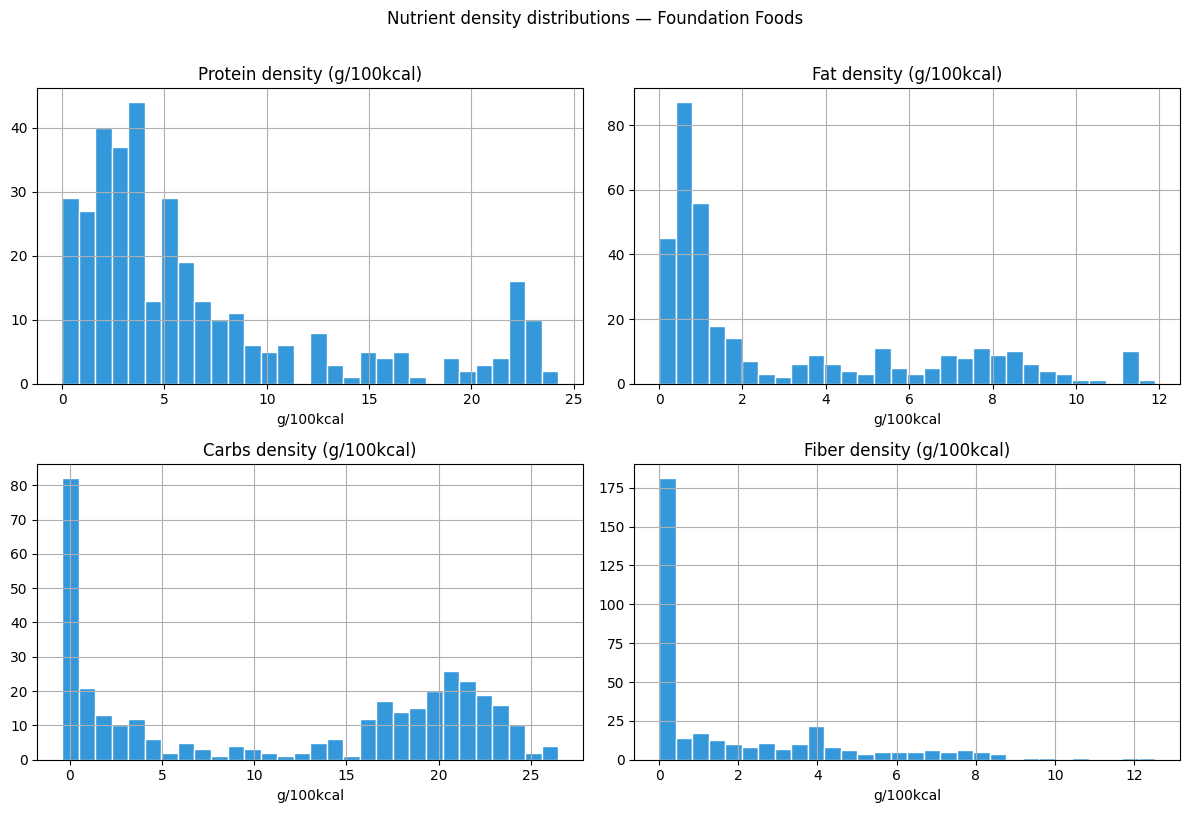

In [23]:
# 4-panel distribution: protein, fat, carbs, fiber per 100kcal
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
pairs = [
    ("Protein_per_100kcal",               "Protein density (g/100kcal)"),
    ("Total_lipid_(fat)_per_100kcal",     "Fat density (g/100kcal)"),
    ("Carbohydrate_by_difference_per_100kcal", "Carbs density (g/100kcal)"),
    ("Fiber_total_dietary_per_100kcal",  "Fiber density (g/100kcal)"),
]
for ax, (col, label) in zip(axes.flat, pairs):
    if col in df.columns:
        df[col].hist(bins=30, ax=ax, color="#3498db", edgecolor="white")
    ax.set_title(label)
    ax.set_xlabel(label.split("(")[1].rstrip(")"))
plt.suptitle("Nutrient density distributions — Foundation Foods", y=1.01)
plt.tight_layout()
plt.show()


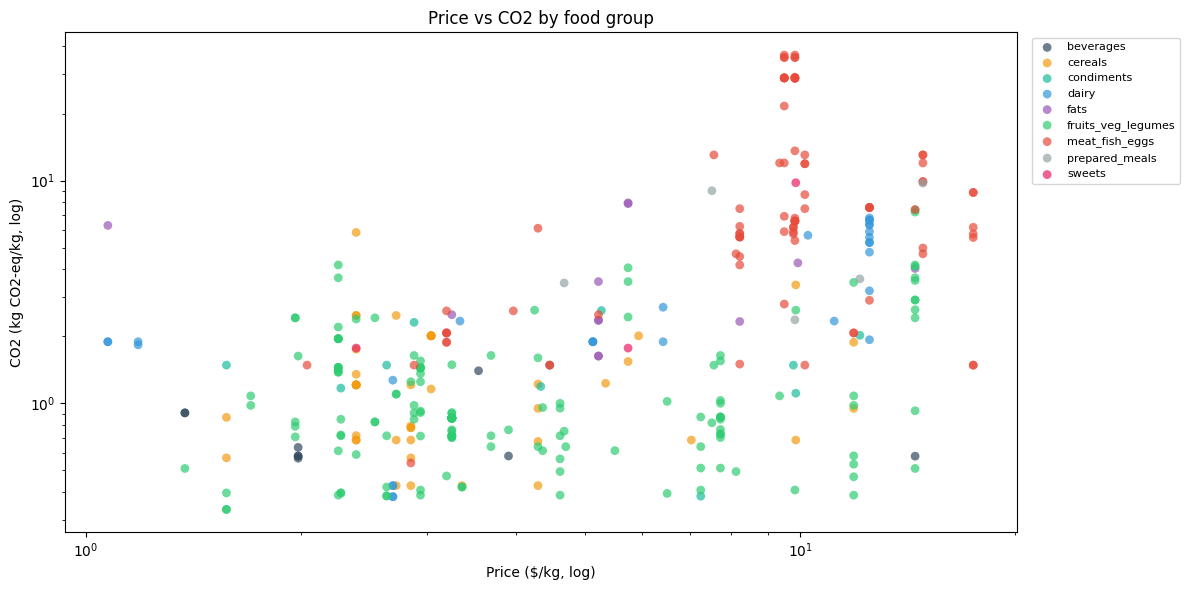

In [24]:
# CO2 vs price scatter (log scale), colored by food group
fig, ax = plt.subplots(figsize=(12, 6))
for grp, grp_df in df.groupby("group_en"):
    ax.scatter(grp_df["price_per_kg"], grp_df["co2_kg_final"],
               label=grp, color=PALETTE.get(grp, PALETTE["default"]),
               alpha=0.7, edgecolors="none", s=40)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Price ($/kg, log)")
ax.set_ylabel("CO2 (kg CO2-eq/kg, log)")
ax.set_title("Price vs CO2 by food group")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


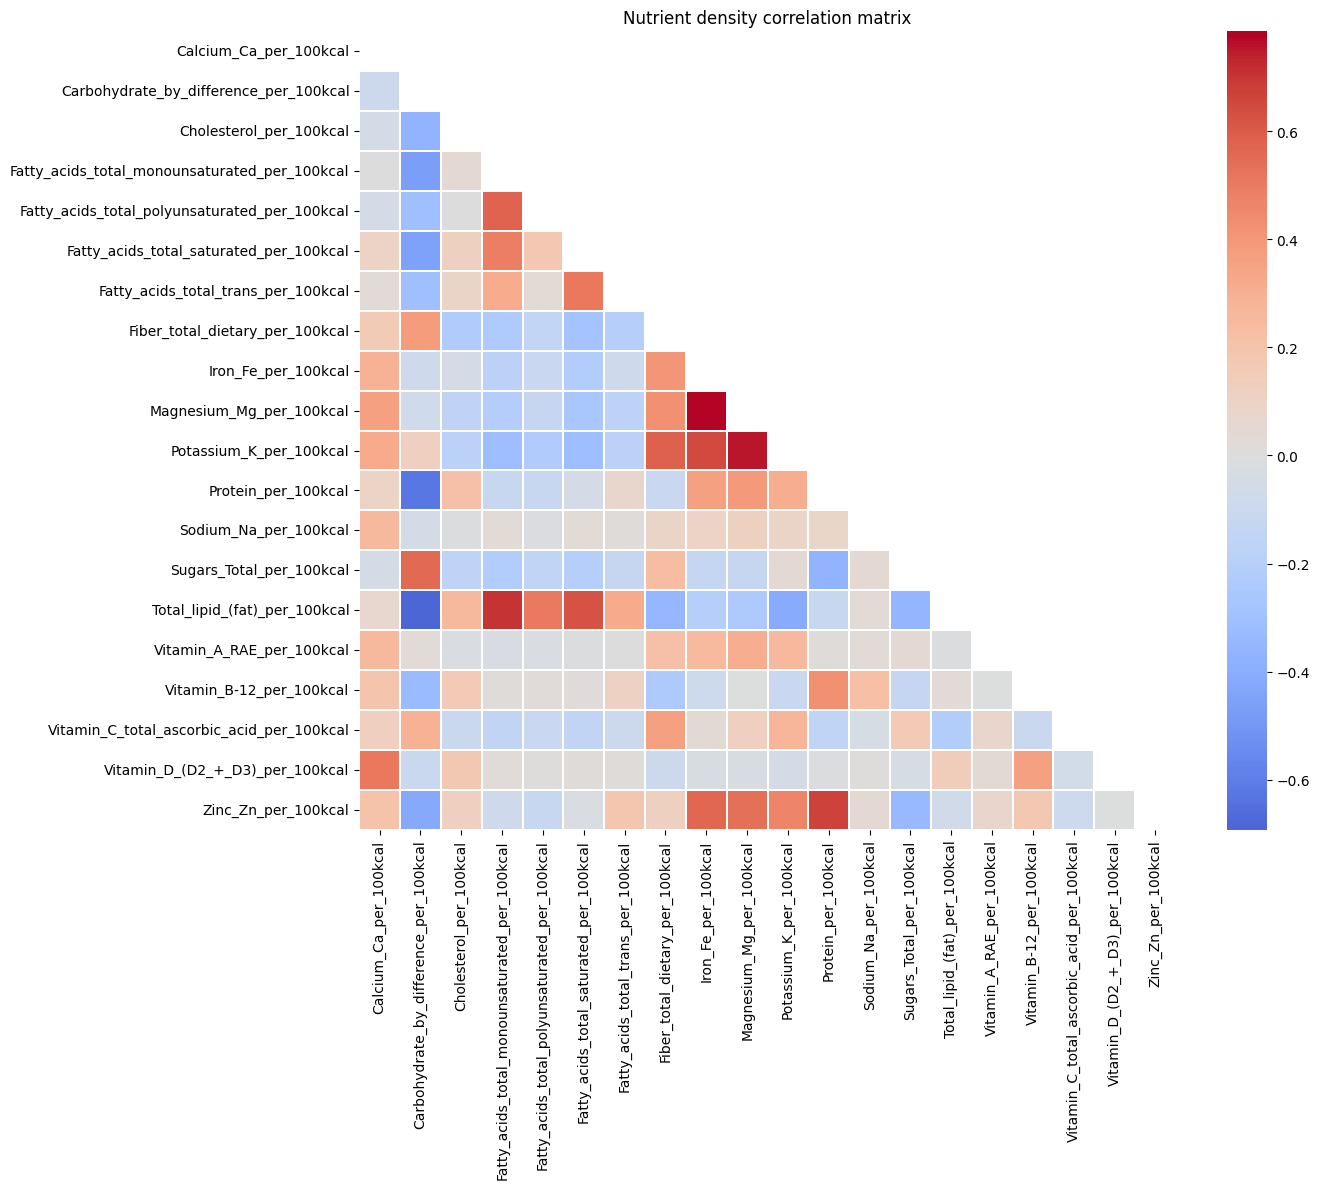

In [25]:
# Correlation heatmap of all density features
corr = df[density_cols].corr()
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            annot=False, linewidths=0.3, ax=ax)
ax.set_title("Nutrient density correlation matrix")
plt.tight_layout()
plt.show()


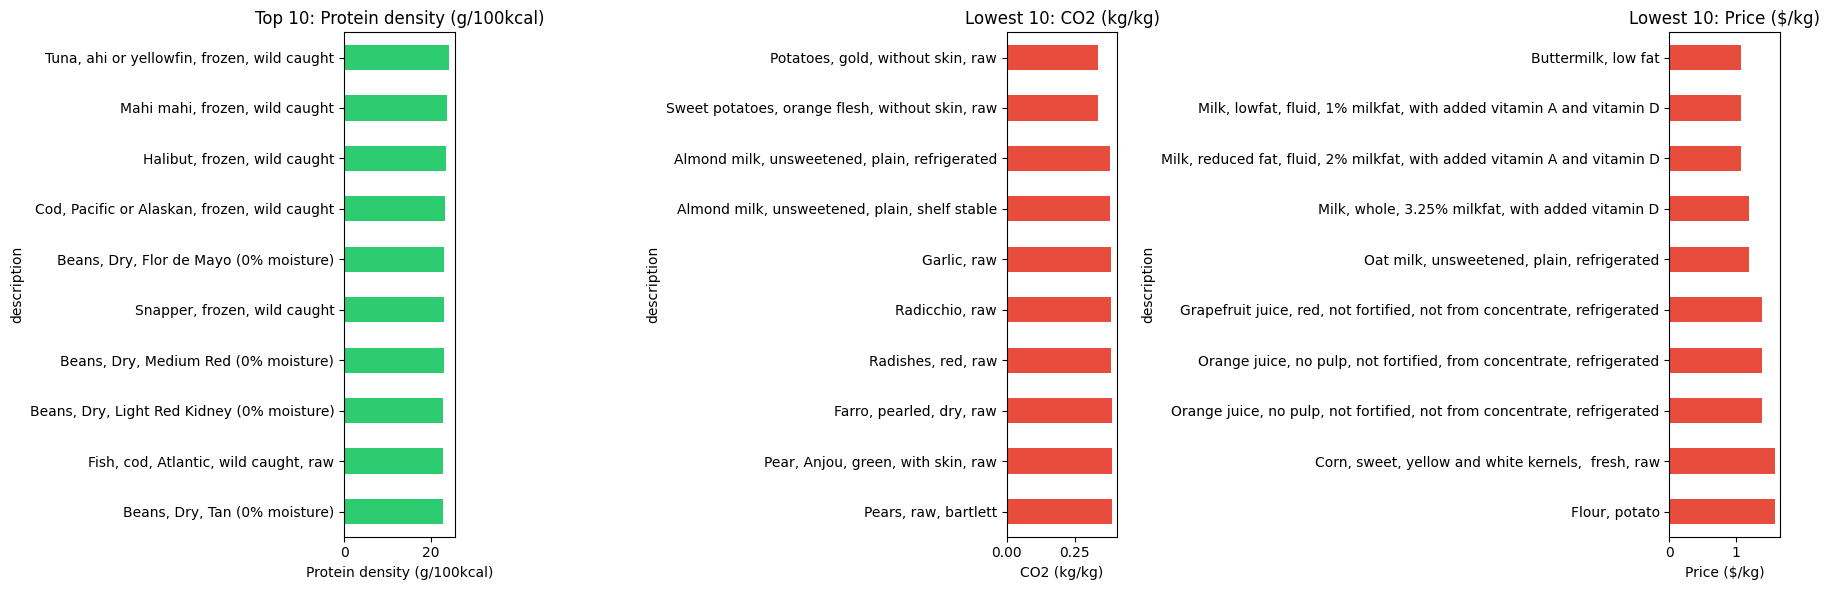

In [26]:
# Top/bottom 10 by protein density, CO2, price
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = [
    ("Protein_per_100kcal",  "Protein density (g/100kcal)", True),
    ("co2_kg_final",         "CO2 (kg/kg)",                 False),
    ("price_per_kg",         "Price ($/kg)",                False),
]
for ax, (col, label, high_is_good) in zip(axes, metrics):
    if col not in df.columns:
        continue
    top10 = df.nlargest(10, col)[["description", col]]
    if not high_is_good:
        top10 = df.nsmallest(10, col)[["description", col]]
    top10.plot(kind="barh", x="description", y=col, ax=ax,
               color="#2ecc71" if high_is_good else "#e74c3c", legend=False)
    ax.set_title(f"{'Top' if high_is_good else 'Lowest'} 10: {label}")
    ax.set_xlabel(label)
    ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [27]:
# Mean nutrients by food group
print("Mean nutrient densities by food group:")
group_summary = df.groupby("group_en")[density_cols[:8]].mean().round(2)
display(group_summary)


Mean nutrient densities by food group:


,Calcium_Ca_per_100kcal,Carbohydrate_by_difference_per_100kcal,Cholesterol_per_100kcal,Fatty_acids_total_monounsaturated_per_100kcal,Fatty_acids_total_polyunsaturated_per_100kcal,Fatty_acids_total_saturated_per_100kcal,Fatty_acids_total_trans_per_100kcal,Fiber_total_dietary_per_100kcal
group_en,,,,,,,,
beverages,20.57,22.32,0.00,0.00,0.00,0.00,0.00,0.49
cereals,10.80,19.23,6.72,0.12,0.09,0.06,0.00,1.44
condiments,34.70,13.11,2.73,1.45,0.48,0.83,0.00,3.93
dairy,268.44,5.25,15.94,1.19,0.26,2.66,0.08,0.02
fats,24.94,0.94,10.18,4.00,1.92,2.43,0.01,0.00
fruits_veg_legumes,74.94,15.84,0.00,0.22,0.20,0.08,0.00,3.20
meat_fish_eggs,39.30,2.53,41.26,1.00,0.36,0.98,0.05,0.69
prepared_meals,53.10,9.88,27.73,0.42,0.48,0.27,0.01,2.19
sweets,26.16,10.59,0.00,1.79,0.65,0.22,0.00,1.00


## 3. PCA

**Why normalize before PCA?** StandardScaler ensures that nutrients with large
absolute values (e.g., Sodium 100s of mg) don't numerically dominate nutrients
with small values (e.g., Vitamin B12 in μg). Without scaling, PCA would mostly
capture variance in the highest-magnitude features.

**PC interpretation (expected):**
- PC1: overall energy substrate split (protein–fat axis)
- PC2: micronutrient richness (minerals + vitamins vs. empty calories)
- PC3: plant vs. animal profile (fiber/potassium vs. cholesterol/B12)


In [28]:
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(df[density_cols])

pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)
for i in range(3):
    df[f"PCA{i+1}"] = X_pca3[:, i]

print("Variance explained per PC:")
for i, v in enumerate(pca3.explained_variance_ratio_, 1):
    print(f"  PC{i}: {v*100:.1f}%")
print(f"  Total (3D): {pca3.explained_variance_ratio_.sum()*100:.1f}%")


Variance explained per PC:
  PC1: 22.6%
  PC2: 18.1%
  PC3: 9.3%
  Total (3D): 50.0%


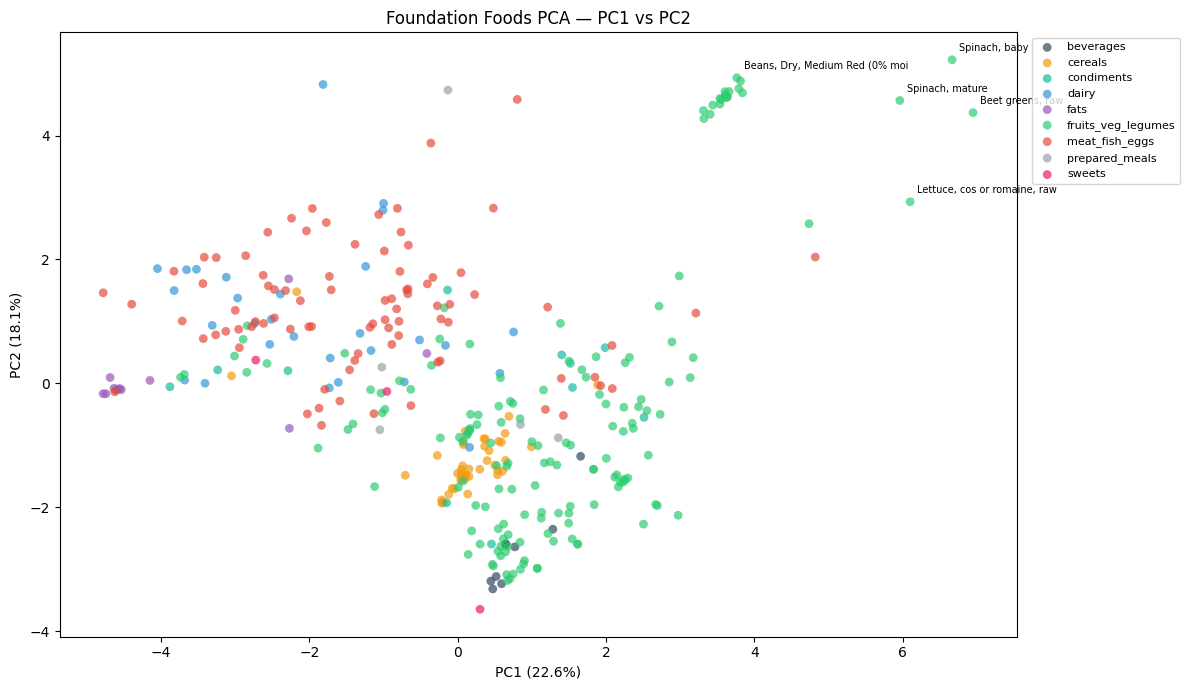

In [29]:
# 2D PCA scatter — label 5 most extreme outliers
fig, ax = plt.subplots(figsize=(12, 7))
for grp, grp_df in df.groupby("group_en"):
    ax.scatter(grp_df["PCA1"], grp_df["PCA2"],
               label=grp, color=PALETTE.get(grp, PALETTE["default"]),
               alpha=0.7, edgecolors="none", s=40)

# Label 5 most extreme by PC1 + PC2 magnitude
extremes = df.assign(dist=(df["PCA1"]**2 + df["PCA2"]**2)**0.5).nlargest(5, "dist")
for _, r in extremes.iterrows():
    ax.annotate(r["description"][:30], (r["PCA1"], r["PCA2"]),
                fontsize=7, ha="left", va="bottom",
                xytext=(5, 5), textcoords="offset points")

ax.set_xlabel(f"PC1 ({pca3.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca3.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Foundation Foods PCA — PC1 vs PC2")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


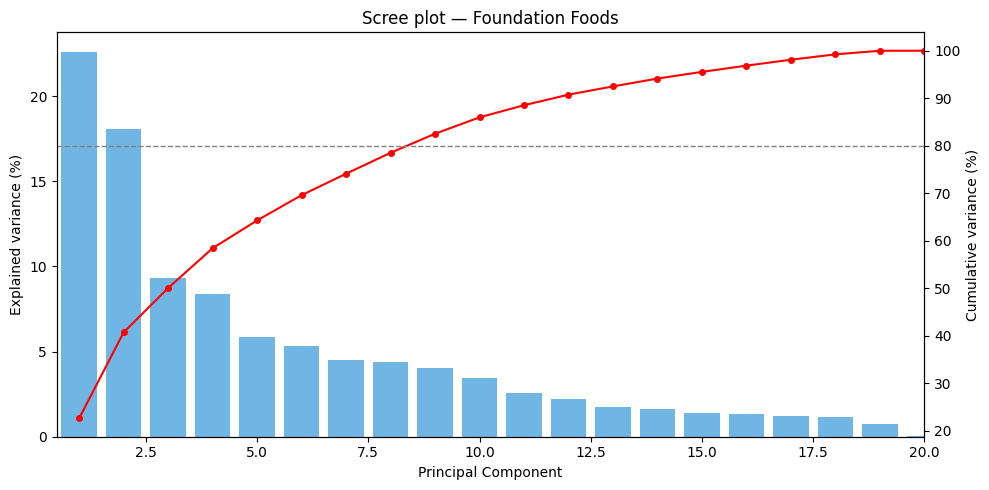

In [30]:
# Scree plot with cumulative variance
pca_full = PCA(random_state=42).fit(X_scaled)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
        pca_full.explained_variance_ratio_ * 100, color="#3498db", alpha=0.7)
ax2.plot(range(1, len(cum_var) + 1), cum_var * 100, "r-o", ms=4)
ax2.axhline(80, ls="--", color="grey", lw=1)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained variance (%)")
ax2.set_ylabel("Cumulative variance (%)")
ax1.set_title("Scree plot — Foundation Foods")
ax1.set_xlim(0.5, 20)
plt.tight_layout()
plt.show()


In [31]:
# Component loadings: top 3 positive and negative contributors for PC1–PC3
loadings = pd.DataFrame(
    pca3.components_,
    columns=density_cols,
    index=["PC1", "PC2", "PC3"],
)
for pc in ["PC1", "PC2", "PC3"]:
    row = loadings.loc[pc].sort_values()
    print(f"\n{pc} — top 3 positive (high = pushed +{pc}):")
    print(row.tail(3).round(3).to_string())
    print(f"{pc} — top 3 negative (high = pushed -{pc}):")
    print(row.head(3).round(3).to_string())



PC1 — top 3 positive (high = pushed +PC1):
Magnesium_Mg_per_100kcal           0.313
Fiber_total_dietary_per_100kcal    0.316
Potassium_K_per_100kcal            0.368
PC1 — top 3 negative (high = pushed -PC1):
Total_lipid_(fat)_per_100kcal                   -0.365
Fatty_acids_total_monounsaturated_per_100kcal   -0.311
Fatty_acids_total_saturated_per_100kcal         -0.299

PC2 — top 3 positive (high = pushed +PC2):
Magnesium_Mg_per_100kcal    0.296
Protein_per_100kcal         0.400
Zinc_Zn_per_100kcal         0.406
PC2 — top 3 negative (high = pushed -PC2):
Carbohydrate_by_difference_per_100kcal      -0.403
Sugars_Total_per_100kcal                    -0.294
Vitamin_C_total_ascorbic_acid_per_100kcal   -0.101

PC3 — top 3 positive (high = pushed +PC3):
Fiber_total_dietary_per_100kcal                  0.302
Fatty_acids_total_polyunsaturated_per_100kcal    0.313
Fatty_acids_total_monounsaturated_per_100kcal    0.365
PC3 — top 3 negative (high = pushed -PC3):
Protein_per_100kcal        -0.3

## 4. Clustering

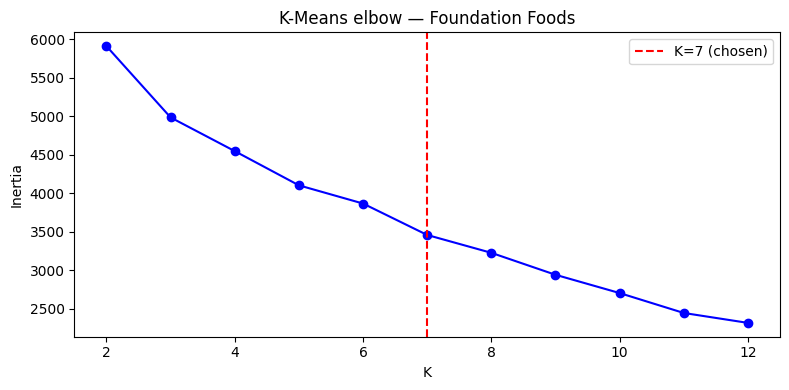

In [32]:
# K-Means elbow plot (K=2 to 12)
inertias = []
ks = range(2, 13)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(ks), inertias, "bo-")
ax.axvline(7, ls="--", color="red", label="K=7 (chosen)")
ax.set_xlabel("K")
ax.set_ylabel("Inertia")
ax.set_title("K-Means elbow — Foundation Foods")
ax.legend()
plt.tight_layout()
plt.show()


In [33]:
# Final K-Means with K=7
N_CLUSTERS = 7
km_final = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df["Cluster_KMeans"] = km_final.fit_predict(X_scaled)

# Hierarchical (Ward) — fit on full data
agg = AgglomerativeClustering(n_clusters=N_CLUSTERS, metric="euclidean", linkage="ward")
df["Cluster"] = agg.fit_predict(X_scaled)
print("Cluster sizes (Hierarchical):")
print(df["Cluster"].value_counts().sort_index())


Cluster sizes (Hierarchical):
Cluster
0     97
1    167
2     22
3     31
4      3
5     22
6     15
Name: count, dtype: int64


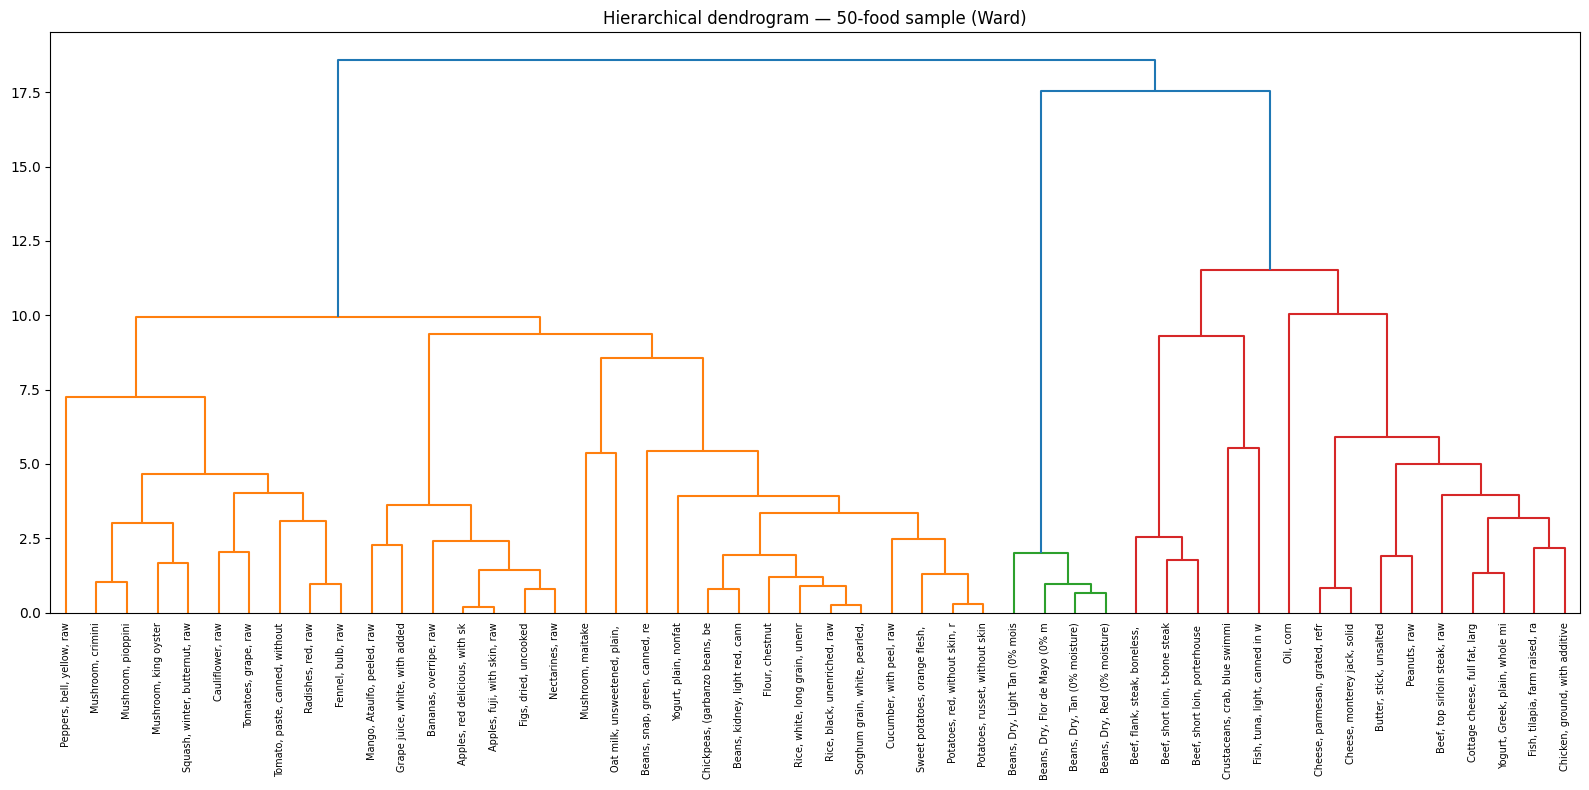

In [34]:
# Dendrogram on 50-sample subset
sample_idx = df.sample(50, random_state=42).index
X_sample   = X_scaled[df.index.get_indexer(sample_idx)]
sample_labels = df.loc[sample_idx, "description"].str[:30].tolist()

linked = linkage(X_sample, method="ward")
fig, ax = plt.subplots(figsize=(16, 8))
dendrogram(linked, labels=sample_labels, ax=ax, leaf_rotation=90, leaf_font_size=7)
ax.set_title("Hierarchical dendrogram — 50-food sample (Ward)")
plt.tight_layout()
plt.show()


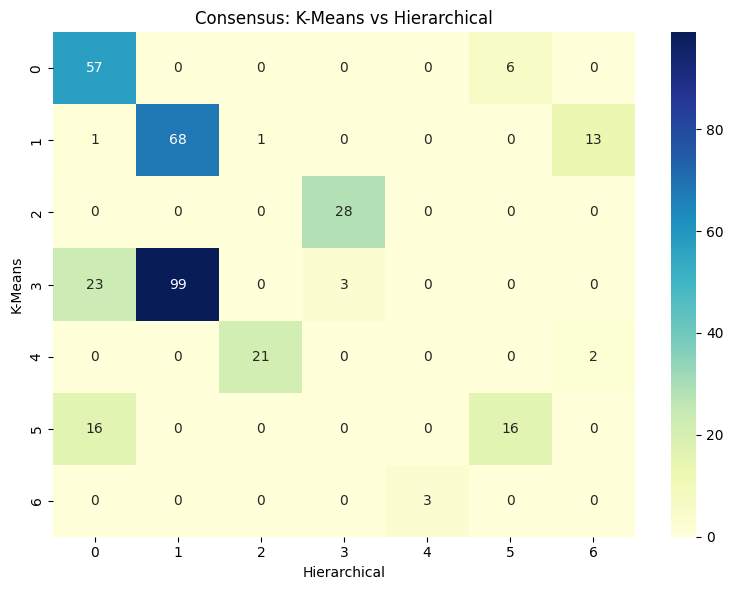

In [35]:
# Consensus heatmap: K-Means vs Hierarchical
ctab = pd.crosstab(df["Cluster_KMeans"], df["Cluster"],
                   rownames=["K-Means"], colnames=["Hierarchical"])
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(ctab, annot=True, fmt="d", cmap="YlGnBu", ax=ax)
ax.set_title("Consensus: K-Means vs Hierarchical")
plt.tight_layout()
plt.show()


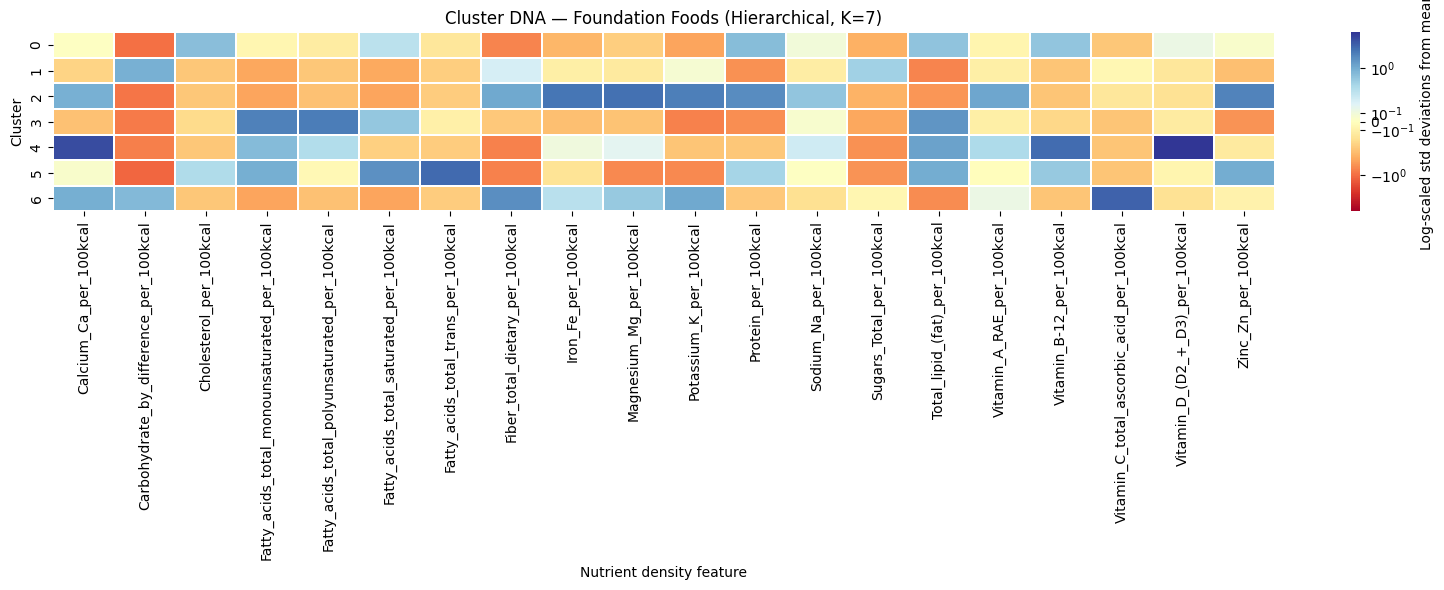

In [36]:
# Cluster DNA heatmap (scaled features × cluster)
scaled_df = pd.DataFrame(X_scaled, columns=density_cols, index=df.index)
scaled_df["Cluster"] = df["Cluster"]
fingerprints = scaled_df.groupby("Cluster").mean()

fig, ax = plt.subplots(figsize=(16, 6))
vmax = fingerprints.abs().max().max()
sns.heatmap(
    fingerprints, cmap="RdYlBu",
    norm=SymLogNorm(linthresh=0.5, vmin=-vmax, vmax=vmax),
    linewidths=0.3, ax=ax,
    cbar_kws={"label": "Log-scaled std deviations from mean"},
)
ax.set_title("Cluster DNA — Foundation Foods (Hierarchical, K=7)")
ax.set_xlabel("Nutrient density feature")
plt.tight_layout()
plt.show()


In [37]:
# Cluster summary: human name, size, avg kcal, 8 example foods
for c in sorted(df["Cluster"].unique()):
    sub = df[df["Cluster"] == c]
    print(f"\nCluster {c}: (n={len(sub)}, "
          f"avg {sub['Energy [kcal]'].mean():.0f} kcal/100g)")
    print("  Examples:", ", ".join(sub["description"].head(8).tolist()))



Cluster 0: (n=97, avg 240 kcal/100g)
  Examples: Anchovies, canned in olive oil, with salt, drained, Avocado, Hass, peeled, raw, Beef, short loin (NY strip steak), raw, Beef, top sirloin steak, raw, Beef, tenderloin steak, raw, Bison, ground, raw, Butter, stick, salted, Butter, stick, unsalted

Cluster 1: (n=167, avg 153 kcal/100g)
  Examples: Apple juice, with added vitamin C, from concentrate, shelf stable, Apples, fuji, with skin, raw, Apples, gala, with skin, raw, Apples, granny smith, with skin, raw, Apples, honeycrisp, with skin, raw, Apples, red delicious, with skin, raw, Applesauce, unsweetened, with added vitamin C, Apricot, with skin, raw

Cluster 2: (n=22, avg 89 kcal/100g)
  Examples: Beans, Dry, Black (0% moisture), Beans, Dry, Brown (0% moisture), Beans, Dry, Carioca (0% moisture), Beans, Dry, Cranberry (0% moisture), Beans, Dry, Dark Red Kidney (0% moisture), Beans, Dry, Flor de Mayo (0% moisture), Beans, Dry, Great Northern (0% moisture), Beans, Dry, Light Red Kidney (

## Cluster Interpretation

The 7 clusters capture distinct nutritional archetypes that emerge naturally from the data, partially but not fully aligned with conventional food group labels:

| Cluster | n | Avg kcal/100g | Nutritional archetype | Representative foods |
|---|---|---|---|---|
| **0** | 97 | 240 | **Mixed high-energy** — diverse group combining fatty animal products, high-fat dairy, and calorie-dense whole foods | Avocado, beef cuts (NY strip, sirloin, tenderloin), bison, butter, canned anchovies |
| **1** | 167 | 153 | **Fruits, juices & moderate-calorie whole foods** — the largest cluster; low fat, moderate carbs, moderate fiber | Apples (all varieties), applesauce, apricot, apple juice |
| **2** | 22 | 89 | **Dry legumes** — zero-moisture beans with very high protein and carbohydrate density per kcal, minimal fat | Black, kidney, cranberry, navy, great northern beans |
| **3** | 31 | 541 | **Energy-dense plant foods** — nuts, seeds, nut butters; high fat and moderate protein per kcal | Almonds, pecans, almond butter, flaxseed, hummus, mustard |
| **4** | 3 | 25 | **Plant-based milk alternatives** — very low calorie, low protein per kcal, distinct from both dairy and beverages | Almond milk (unsweetened, refrigerated and shelf-stable), sweetened soy milk |
| **5** | 22 | 252 | **Lean red meat** — beef cuts with high protein density, moderate fat, very low carbs | Ground beef (80/20 and 90/10), chuck roast, flank steak, ribeye, round |
| **6** | 15 | 32 | **Non-starchy vegetables** — very low calorie, high fiber and micronutrient density per kcal, minimal fat | Arugula, broccoli, Brussels sprouts, bok choy, cauliflower, collards, kale |

**Key observations:**
- Clusters 5 (lean red meat) and 0 (mixed high-energy, which contains fattier beef cuts and butter) show that conventional "meat" and "dairy" labels mask important nutritional distinctions — K-Means separates them correctly.
- Cluster 4 (plant milks, n=3) is an outlier cluster driven by the unique nutritional signature of fortified, diluted beverages — very low calorie density with artificially elevated micronutrient ratios per 100 kcal.
- Cluster 2 (dry legumes) is nutritionally distinct from Cluster 1 (fresh fruits/vegetables) despite both being plant-based: legumes have much higher protein and carbohydrate content per kcal.
- Cluster 3 (nuts/seeds) overlaps with Cluster 0 in raw caloric density but is separated by fatty acid profile — plant unsaturated fats vs. animal saturated fats.

## 5. Save

In [38]:
df.to_csv("foundation_clustered.csv", index=False)
print("Saved: foundation_clustered.csv")
print("Columns added: PCA1, PCA2, PCA3, Cluster_KMeans, Cluster")
print("Shape:", df.shape)


Saved: foundation_clustered.csv
Columns added: PCA1, PCA2, PCA3, Cluster_KMeans, Cluster
Shape: (357, 38)
